# Etapa 2 — Modelagem com Redes Neurais

Nesta etapa, o objetivo é construir, treinar e avaliar uma rede neural do tipo MLP para o problema de previsão de churn.

A MLP será comparada com os modelos baseline desenvolvidos na etapa anterior, especialmente a Regressão Logística, que apresentou bom desempenho inicial.

A comparação será feita usando métricas técnicas e também a lógica de custo associada a falsos positivos e falsos negativos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    classification_report,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    confusion_matrix
)

import mlflow
import mlflow.pytorch
from pathlib import Path
import joblib
import json
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, roc_auc_score

In [2]:
# Configuração Inicial

RANDOM_STATE = 555
LOG_MLFLOW = False

# Fixando a aleatoriedade do NumPy e do PyTorch para garantir reprodutibilidade
np.random.seed(RANDOM_STATE) 
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [3]:
df = pd.read_csv("../data/processed/churn_clean.csv")

df.shape

(7032, 24)

In [4]:
drop_cols = ['Country', 'State', 'City', 'Zip Code']

X = df.drop(['Churn Value'] + drop_cols, axis=1)
y = df['Churn Value'].astype(int)

X.shape, y.shape

((7032, 19), (7032,))

In [5]:
# Separação de Treino, Validação e Teste
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Train:", y_train.value_counts(normalize=True))
print("Val:", y_val.value_counts(normalize=True))
print("Test:", y_test.value_counts(normalize=True))

Train: Churn Value
0    0.734254
1    0.265746
Name: proportion, dtype: float64
Val: Churn Value
0    0.733649
1    0.266351
Name: proportion, dtype: float64
Test: Churn Value
0    0.734597
1    0.265403
Name: proportion, dtype: float64


In [6]:
# Pre-Processamento - OneHotEncoder+StandartScaler
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])


X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

# Conversão para tensor
X_train_tensor = torch.tensor(X_train_proc, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_proc, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_proc, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

X_train_tensor.shape, y_train_tensor.shape

(torch.Size([4922, 46]), torch.Size([4922, 1]))

In [7]:
# Configurando batches e criando os DataLoaders
batch_size = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [8]:
# Arquitetura do MLP
class ChurnMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(16, 1)
        )
        
    def forward(self, x):
        return self.network(x)

In [9]:
# Medindo o Loss e ajustando os pesos (Optimizer)
input_dim = X_train_tensor.shape[1]

model = ChurnMLP(input_dim).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model

ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=46, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [10]:
# Função de Treino e Função de Validação
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(train_loader.dataset)


def evaluate_loss(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(data_loader.dataset)

In [11]:
# Loop de Treinamento
epochs = 100 # máximo de épocas/rodadas
patience = 10 # Tolerância para early stopping

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

history = []

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate_loss(model, val_loader, criterion, device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    print(f"Epoch {epoch:03d} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_model_state)

Epoch 001 | train_loss: 0.5780 | val_loss: 0.4567
Epoch 002 | train_loss: 0.4438 | val_loss: 0.3990
Epoch 003 | train_loss: 0.4286 | val_loss: 0.3894
Epoch 004 | train_loss: 0.4224 | val_loss: 0.3857
Epoch 005 | train_loss: 0.4172 | val_loss: 0.3812
Epoch 006 | train_loss: 0.4162 | val_loss: 0.3812
Epoch 007 | train_loss: 0.4115 | val_loss: 0.3791
Epoch 008 | train_loss: 0.4060 | val_loss: 0.3778
Epoch 009 | train_loss: 0.4088 | val_loss: 0.3784
Epoch 010 | train_loss: 0.4099 | val_loss: 0.3852
Epoch 011 | train_loss: 0.4079 | val_loss: 0.3784
Epoch 012 | train_loss: 0.4035 | val_loss: 0.3786
Epoch 013 | train_loss: 0.4063 | val_loss: 0.3786
Epoch 014 | train_loss: 0.4051 | val_loss: 0.3766
Epoch 015 | train_loss: 0.4037 | val_loss: 0.3792
Epoch 016 | train_loss: 0.4073 | val_loss: 0.3765
Epoch 017 | train_loss: 0.4032 | val_loss: 0.3758
Epoch 018 | train_loss: 0.4015 | val_loss: 0.3768
Epoch 019 | train_loss: 0.3997 | val_loss: 0.3793
Epoch 020 | train_loss: 0.3986 | val_loss: 0.3733


<All keys matched successfully>

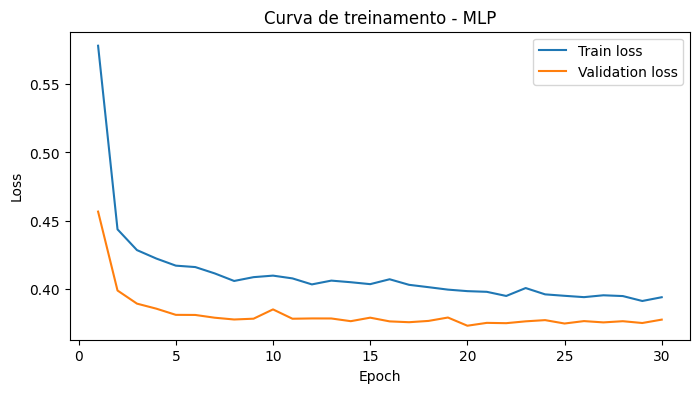

In [12]:
# Curva de Loss

history_df = pd.DataFrame(history)

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curva de treinamento - MLP")
plt.legend()
plt.show()

In [13]:
# Avaliação no teste
model.eval()

with torch.no_grad():
    logits_test = model(X_test_tensor.to(device))
    y_proba_mlp = torch.sigmoid(logits_test).cpu().numpy().ravel()

y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)

print(classification_report(y_test, y_pred_mlp))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_mlp))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87       775
           1       0.66      0.44      0.53       280

    accuracy                           0.79      1055
   macro avg       0.74      0.68      0.70      1055
weighted avg       0.78      0.79      0.78      1055

AUC-ROC: 0.83336866359447


In [14]:
# Avaliação de diferentes thresholds
thresholds = [0.5, 0.4, 0.3, 0.2]

for t in thresholds:
    y_pred = (y_proba_mlp >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.82      0.92      0.87       775
           1       0.66      0.44      0.53       280

    accuracy                           0.79      1055
   macro avg       0.74      0.68      0.70      1055
weighted avg       0.78      0.79      0.78      1055


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       775
           1       0.58      0.56      0.57       280

    accuracy                           0.78      1055
   macro avg       0.71      0.71      0.71      1055
weighted avg       0.77      0.78      0.78      1055


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.88      0.77      0.82       775
           1       0.52      0.70      0.60       280

    accuracy                           0.75      1055
   macro avg       0.70      0.74      0.71      1055
weighted avg       0.78   

In [15]:
ticket_medio_churn = df.loc[df['Churn Value'] == 1, 'Monthly Charges'].mean()

meses_retencao = 3
custo_fp = 100
custo_fn = ticket_medio_churn * meses_retencao

thresholds = np.arange(0.10, 0.91, 0.05)

resultados_mlp = []

for t in thresholds:
    y_pred = (y_proba_mlp >= t).astype(int)
    
    fp = ((y_pred == 1) & (y_test.values == 0)).sum()
    fn = ((y_pred == 0) & (y_test.values == 1)).sum()
    tp = ((y_pred == 1) & (y_test.values == 1)).sum()
    tn = ((y_pred == 0) & (y_test.values == 0)).sum()
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    
    custo_total = fp * custo_fp + fn * custo_fn
    valor_retido = tp * custo_fn
    valor_liquido = valor_retido - (fp * custo_fp)
    
    resultados_mlp.append({
        'threshold': round(t, 2),
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'tn': tn,
        'recall': recall,
        'precision': precision,
        'f1_score': f1,
        'accuracy': accuracy,
        'custo_total': custo_total,
        'valor_liquido': valor_liquido
    })

df_resultados_mlp = pd.DataFrame(resultados_mlp)

df_resultados_mlp.sort_values(by='valor_liquido', ascending=False).head(10)

,threshold,fp,fn,tp,tn,recall,precision,f1_score,accuracy,custo_total,valor_liquido
3,0.25,215,61,219,560,0.782143,0.504608,0.613445,0.738389,35122.763804,27407.955297
2,0.20,277,37,243,498,0.867857,0.467308,0.607500,0.702370,35962.987881,26567.731220
4,0.30,180,83,197,595,0.703571,0.522546,0.599696,0.750711,36535.891734,25994.827368
1,0.15,315,25,255,460,0.910714,0.447368,0.600000,0.677725,37083.099920,25447.619181
5,0.35,147,103,177,628,0.632143,0.546296,0.586093,0.763033,37702.371669,24828.347432
6,0.40,111,124,156,664,0.557143,0.584270,0.570384,0.777251,38792.175602,23738.543499
0,0.10,354,18,262,421,0.935714,0.425325,0.584821,0.647393,39419.831942,23110.887159
7,0.45,87,140,140,688,0.500000,0.616740,0.552268,0.784834,39965.359551,22565.359551
8,0.50,63,157,123,712,0.439286,0.661290,0.527897,0.791469,41361.867496,21168.851605
9,0.55,45,169,111,730,0.396429,0.711538,0.509174,0.797156,42241.755457,20288.963644


### Comparação econômica entre modelos

A MLP foi construída para capturar relações não lineares entre as variáveis de cliente e a probabilidade de churn. O treinamento foi realizado com batches (64) e early stopping (10 epocs), utilizando uma base de validação para controlar overfitting. Embora a rede tenha apresentado AUC próxima ao baseline linear, sua performance inicial com threshold 0.5 foi mais conservadora, com menor recall da classe churn. Nesse contexto, assim como no baseline, faz-se necessário uma análise técnica dos diferentes thresholds e seus possíveis impactos econômicos.

A análise de valor econômico mostrou que, embora a MLP apresente maior recall em determinados thresholds, esse ganho é acompanhado por um aumento significativo no número de falsos positivos, elevando o custo das ações de retenção.

Como resultado, o valor líquido gerado pelo modelo é inferior ao obtido com a Regressão Logística, mesmo quando ajustada por threshold.

Esse resultado reforça que a escolha do modelo não deve se basear apenas em métricas técnicas isoladas, mas sim em sua capacidade de gerar valor dentro do contexto de negócio.

No caso analisado, o modelo linear se mostrou mais eficiente, possivelmente devido à natureza estruturada das variáveis explicativas.

### Registro no MLFow


In [16]:

PROJECT_ROOT = Path.cwd().parent
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"
MLFLOW_ARTIFACTS = PROJECT_ROOT / "mlruns"
MLFLOW_ARTIFACTS.mkdir(exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB.as_posix()}")
mlflow.set_experiment("churn_neural_networks")

<Experiment: artifact_location=('file:///c:/Users/mateu/OneDrive/FIAP - '
 'Pós/FASE1/TechChallenge/notebooks/mlruns/2'), creation_time=1777562473268, experiment_id='2', last_update_time=1777562473268, lifecycle_stage='active', name='churn_neural_networks', tags={}, trace_location=None, workspace='default'>

In [17]:
best_mlp_threshold = df_resultados_mlp.sort_values(
    by='valor_liquido', ascending=False
).iloc[0]
best_threshold_mlp = best_mlp_threshold['threshold']


y_pred_mlp_025 = (y_proba_mlp >= best_threshold_mlp).astype(int)

if LOG_MLFLOW:
    with mlflow.start_run(run_name="mlp_baseline"):
        mlflow.log_param("model_type", "MLP")
        mlflow.log_param("hidden_layers", "32,16")
        mlflow.log_param("activation", "ReLU")
        mlflow.log_param("dropout", 0.2)
        mlflow.log_param("loss", "BCEWithLogitsLoss")
        mlflow.log_param("optimizer", "Adam")
        mlflow.log_param("learning_rate", 0.001)
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("epochs_max", epochs)
        mlflow.log_param("patience", patience)
        mlflow.log_param("threshold", best_threshold_mlp)
        mlflow.log_param("meses_retencao", meses_retencao)
        mlflow.log_param("custo_fp", custo_fp)
        mlflow.log_param("custo_fn", custo_fn)

        mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_mlp_025))
        mlflow.log_metric("precision_churn", precision_score(y_test, y_pred_mlp_025))
        mlflow.log_metric("recall_churn", recall_score(y_test, y_pred_mlp_025))
        mlflow.log_metric("f1_churn", f1_score(y_test, y_pred_mlp_025))
        mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_proba_mlp))

        mlflow.log_metric("best_val_loss", best_val_loss)
        mlflow.log_metric("valor_liquido", best_mlp_threshold["valor_liquido"])
        mlflow.log_metric("custo_total", best_mlp_threshold["custo_total"])

        mlflow.pytorch.log_model(model, name="mlp_baseline")

### MLP com class weights

Uma ideia para tentar melhorar o desempenho do nosso mlp é que, dado o desbalanceamento da variável alvo e o maior custo associado à não identificação de clientes que irão churnar, vamos utilizar uma função de perda ponderada (class weights), atribuindo maior penalização aos erros da classe positiva.

Essa abordagem permite que o modelo internalize, durante o treinamento, a assimetria de custos já observada na análise de negócio.

In [18]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)

pos_weight

tensor([2.7630])

In [19]:
# Recriando um modelo de MLP
model_weighted = ChurnMLP(input_dim).to(device)

criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_weighted = torch.optim.Adam(model_weighted.parameters(), lr=0.001)

In [20]:
# Treinando com o mesmo Loop de Treinamento

best_val_loss_weighted = float("inf")
best_model_state_weighted = None
epochs_without_improvement = 0

history_weighted = []

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(
        model_weighted,
        train_loader,
        criterion_weighted,
        optimizer_weighted,
        device
    )
    
    val_loss = evaluate_loss(
        model_weighted,
        val_loader,
        criterion_weighted,
        device
    )

    history_weighted.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    print(f"Epoch {epoch:03d} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}")

    if val_loss < best_val_loss_weighted:
        best_val_loss_weighted = val_loss
        best_model_state_weighted = model_weighted.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model_weighted.load_state_dict(best_model_state_weighted)

Epoch 001 | train_loss: 0.9079 | val_loss: 0.7166
Epoch 002 | train_loss: 0.7510 | val_loss: 0.6703
Epoch 003 | train_loss: 0.7321 | val_loss: 0.6636
Epoch 004 | train_loss: 0.7162 | val_loss: 0.6632
Epoch 005 | train_loss: 0.7159 | val_loss: 0.6587
Epoch 006 | train_loss: 0.7083 | val_loss: 0.6581
Epoch 007 | train_loss: 0.7062 | val_loss: 0.6544
Epoch 008 | train_loss: 0.6998 | val_loss: 0.6511
Epoch 009 | train_loss: 0.6979 | val_loss: 0.6510
Epoch 010 | train_loss: 0.6918 | val_loss: 0.6452
Epoch 011 | train_loss: 0.6919 | val_loss: 0.6453
Epoch 012 | train_loss: 0.6864 | val_loss: 0.6451
Epoch 013 | train_loss: 0.6829 | val_loss: 0.6417
Epoch 014 | train_loss: 0.6836 | val_loss: 0.6422
Epoch 015 | train_loss: 0.6826 | val_loss: 0.6412
Epoch 016 | train_loss: 0.6800 | val_loss: 0.6412
Epoch 017 | train_loss: 0.6749 | val_loss: 0.6374
Epoch 018 | train_loss: 0.6727 | val_loss: 0.6350
Epoch 019 | train_loss: 0.6733 | val_loss: 0.6387
Epoch 020 | train_loss: 0.6674 | val_loss: 0.6353


<All keys matched successfully>

In [21]:
# Avaliar no teste
model_weighted.eval()

with torch.no_grad():
    logits_test_weighted = model_weighted(X_test_tensor.to(device))
    y_proba_mlp_weighted = torch.sigmoid(logits_test_weighted).cpu().numpy().ravel()

y_pred_mlp_weighted = (y_proba_mlp_weighted >= 0.5).astype(int)

print(classification_report(y_test, y_pred_mlp_weighted))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_mlp_weighted))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80       775
           1       0.49      0.77      0.60       280

    accuracy                           0.73      1055
   macro avg       0.69      0.74      0.70      1055
weighted avg       0.79      0.73      0.74      1055

AUC-ROC: 0.8342165898617512


In [22]:
thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    y_pred = (y_proba_mlp_weighted >= t).astype(int)
    print(f"TH: {t:.2f}")
    print(classification_report(y_test, y_pred))

TH: 0.10
              precision    recall  f1-score   support

           0       0.96      0.41      0.58       775
           1       0.37      0.95      0.53       280

    accuracy                           0.56      1055
   macro avg       0.67      0.68      0.55      1055
weighted avg       0.80      0.56      0.56      1055

TH: 0.15
              precision    recall  f1-score   support

           0       0.97      0.47      0.63       775
           1       0.39      0.95      0.56       280

    accuracy                           0.60      1055
   macro avg       0.68      0.71      0.60      1055
weighted avg       0.81      0.60      0.61      1055

TH: 0.20
              precision    recall  f1-score   support

           0       0.96      0.51      0.66       775
           1       0.41      0.94      0.57       280

    accuracy                           0.62      1055
   macro avg       0.68      0.72      0.61      1055
weighted avg       0.81      0.62      0.64    

In [23]:
# Probabilidades do MLP com class weights
y_proba = y_proba_mlp_weighted

# Parâmetros de negócio
ticket_medio_churn = df.loc[df['Churn Value'] == 1, 'Monthly Charges'].mean()

meses_retencao = 3
custo_fp = 100
custo_fn = ticket_medio_churn * meses_retencao

thresholds = np.arange(0.10, 0.91, 0.05)

resultados_mlp_weighted = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    fp = ((y_pred == 1) & (y_test.values == 0)).sum()
    fn = ((y_pred == 0) & (y_test.values == 1)).sum()
    tp = ((y_pred == 1) & (y_test.values == 1)).sum()
    tn = ((y_pred == 0) & (y_test.values == 0)).sum()

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    custo_total = fp * custo_fp + fn * custo_fn
    valor_retido = tp * custo_fn
    valor_liquido = valor_retido - (fp * custo_fp)

    resultados_mlp_weighted.append({
        'threshold': round(float(t), 2),
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'tn': tn,
        'recall': recall,
        'precision': precision,
        'f1_score': f1,
        'accuracy': accuracy,
        'custo_total': custo_total,
        'valor_liquido': valor_liquido
    })

df_resultados_mlp_weighted = pd.DataFrame(resultados_mlp_weighted)

df_resultados_mlp_weighted.sort_values(
    by='valor_liquido',
    ascending=False
).head(10)

,threshold,fp,fn,tp,tn,recall,precision,f1_score,accuracy,custo_total,valor_liquido
5,0.35,303,27,253,472,0.903571,0.455036,0.605263,0.687204,36329.747913,26200.971188
11,0.65,135,103,177,640,0.632143,0.567308,0.597973,0.774408,36502.371669,26028.347432
8,0.50,220,65,215,555,0.767857,0.494253,0.601399,0.729858,36516.059791,26014.659310
9,0.55,184,82,198,591,0.707143,0.518325,0.598187,0.747867,36712.567737,25818.151364
6,0.40,285,38,242,490,0.864286,0.459203,0.599752,0.693839,36986.311878,25544.407223
10,0.60,163,93,187,612,0.667857,0.534286,0.593651,0.757346,37069.131701,25461.587400
7,0.45,257,51,229,518,0.817857,0.471193,0.597911,0.708057,37089.523836,25441.195265
12,0.70,103,120,160,672,0.571429,0.608365,0.589319,0.788626,37098.879615,25431.839486
4,0.30,328,22,258,447,0.921429,0.440273,0.595843,0.668246,37713.127929,24817.591172
13,0.75,80,139,141,695,0.503571,0.638009,0.562874,0.792417,39042.035554,23488.683547


In [24]:
best_mlp_weighted_threshold = df_resultados_mlp_weighted.sort_values(
    by='valor_liquido',
    ascending=False
).iloc[0]
best_threshold_weighted = float(best_mlp_weighted_threshold["threshold"])

y_pred_weighted_best = (y_proba_mlp_weighted >= best_threshold_weighted).astype(int)

if LOG_MLFLOW:
    with mlflow.start_run(run_name="mlp_class_weights"):
        mlflow.log_param("model_type", "MLP")
        mlflow.log_param("hidden_layers", "32,16")
        mlflow.log_param("activation", "ReLU")
        mlflow.log_param("dropout", 0.2)
        mlflow.log_param("loss", "BCEWithLogitsLoss")
        mlflow.log_param("class_weights", True)
        mlflow.log_param("pos_weight", float(pos_weight.item()))
        mlflow.log_param("optimizer", "Adam")
        mlflow.log_param("learning_rate", 0.001)
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("epochs_max", epochs)
        mlflow.log_param("patience", patience)

        mlflow.log_param("threshold", best_threshold_weighted)
        mlflow.log_param("meses_retencao", meses_retencao)
        mlflow.log_param("custo_fp", custo_fp)
        mlflow.log_param("custo_fn", float(custo_fn))

        mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_weighted_best))
        mlflow.log_metric("precision_churn", precision_score(y_test, y_pred_weighted_best))
        mlflow.log_metric("recall_churn", recall_score(y_test, y_pred_weighted_best))
        mlflow.log_metric("f1_churn", f1_score(y_test, y_pred_weighted_best))
        mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_proba_mlp_weighted))

        mlflow.log_metric("best_val_loss", best_val_loss_weighted)
        mlflow.log_metric("valor_liquido", float(best_mlp_weighted_threshold["valor_liquido"]))
        mlflow.log_metric("custo_total", float(best_mlp_weighted_threshold["custo_total"]))

        mlflow.pytorch.log_model(model_weighted, name="mlp_class_weights")

A utilização de class weights aumentou significativamente o recall da classe churn, porém ao custo de um aumento relevante nos falsos positivos.

Esse aumento no volume de clientes tratados como churn elevou o custo total das ações de retenção, reduzindo o valor líquido do modelo.

Isso evidencia que otimizações puramente técnicas, como o aumento do recall via ponderação da loss, não necessariamente se traduzem em melhores resultados de negócio.

### Tabela Comparativa

In [25]:
# Puxando os dados do Mlflow para comparação
experiment_names = [
    "churn_baseline",
    "churn_neural_networks",
]

all_runs = []

for name in experiment_names:
    experiment = mlflow.get_experiment_by_name(name)

    if experiment is None:
        print(f"Experimento não encontrado: {name}")
        continue

    runs = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        output_format="pandas"
    )

    runs["experiment_name"] = name
    all_runs.append(runs)

df_runs = pd.concat(all_runs, ignore_index=True)

df_runs.head()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.recall_churn,metrics.accuracy,metrics.tp,metrics.fp,...,params.class_weights,params.optimizer,params.dropout,params.patience,params.batch_size,params.model_type,params.learning_rate,params.hidden_layers,params.activation,params.pos_weight
0,9d99b2f9361c43759b15ff05e97438e8,1,FINISHED,file:///c:/Users/mateu/OneDrive/FIAP - Pós/FAS...,2026-05-05 01:10:43.199000+00:00,2026-05-05 01:10:52.264000+00:00,0.556150,0.801706,208.0,113.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0c8d96f868cc47ebb67b3715d48e2b1e,1,FINISHED,file:///c:/Users/mateu/OneDrive/FIAP - Pós/FAS...,2026-05-05 01:10:32.989000+00:00,2026-05-05 01:10:42.779000+00:00,0.655080,0.810945,245.0,137.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,e659f67b5daf420ebab812baf24c0522,1,FINISHED,file:///c:/Users/mateu/OneDrive/FIAP - Pós/FAS...,2026-05-05 01:10:24.019000+00:00,2026-05-05 01:10:32.607000+00:00,0.000000,0.734186,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1ba44122c1df45f984fe6fbe10ac55be,1,FINISHED,file:///c:/Users/mateu/OneDrive/FIAP - Pós/FAS...,2026-05-05 01:10:23.748000+00:00,2026-05-05 01:10:23.955000+00:00,0.655080,0.810945,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1e24c0bade6e45f5b6d501930545e040,1,FINISHED,file:///c:/Users/mateu/OneDrive/FIAP - Pós/FAS...,2026-05-05 01:10:14.389000+00:00,2026-05-05 01:10:23.470000+00:00,0.540107,0.804549,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
comparison_cols = [
    "experiment_name",
    "params.model_name",
    "tags.mlflow.runName",
    "metrics.accuracy",
    "metrics.precision_churn",
    "metrics.recall_churn",
    "metrics.f1_churn",
    "metrics.roc_auc",
    "metrics.best_val_loss",
    "metrics.valor_liquido",
    "metrics.custo_total",
]

model_comparison = df_runs[comparison_cols].copy()

model_comparison = model_comparison.rename(columns={
    "params.model_name": "model_name",
    "tags.mlflow.runName": "run_name",
    "metrics.accuracy": "accuracy",
    "metrics.precision_churn": "precision_churn",
    "metrics.recall_churn": "recall_churn",
    "metrics.f1_churn": "f1_churn",
    "metrics.roc_auc": "roc_auc",
    "metrics.best_val_loss": "best_val_loss",
    "metrics.valor_liquido": "valor_liquido",
    "metrics.custo_total": "custo_total",
})

model_comparison = model_comparison.sort_values(
    by="roc_auc",
    ascending=False,
    na_position="last"
)

model_comparison["model_name"] = model_comparison["model_name"].fillna(
    model_comparison["run_name"]
)

model_comparison

,experiment_name,model_name,run_name,accuracy,precision_churn,recall_churn,f1_churn,roc_auc,best_val_loss,valor_liquido,custo_total
1,churn_baseline,logistic_regression,logistic_regression_with_cost,0.810945,0.641361,0.655080,0.648148,0.855537,NaN,41014.379213,42508.795586
5,churn_baseline,logistic_regression,logistic_regression,0.815210,0.669643,0.601604,0.633803,0.855537,NaN,NaN,NaN
9,churn_baseline,logistic_regression,logistic_regression,0.804549,0.641026,0.601604,0.620690,0.843055,NaN,NaN,NaN
4,churn_baseline,random_forest,random_forest,0.804549,0.662295,0.540107,0.594993,0.841312,NaN,NaN,NaN
0,churn_baseline,random_forest,random_forest_with_cost,0.801706,0.647975,0.556150,0.598561,0.841312,NaN,35151.391332,48371.783467
11,churn_neural_networks,mlp_class_weights,mlp_class_weights,0.687204,0.455036,0.903571,0.605263,0.834217,0.631922,26200.971188,36329.747913
12,churn_neural_networks,mlp_baseline,mlp_baseline,0.738389,0.504608,0.782143,0.613445,0.833369,0.373277,27407.955297,35122.763804
8,churn_baseline,random_forest,random_forest,0.792466,0.633987,0.518717,0.570588,0.828850,NaN,NaN,NaN
2,churn_baseline,dummy,dummy_with_cost,0.734186,0.000000,0.000000,0.000000,0.500000,NaN,0.000000,83523.174799
6,churn_baseline,dummy,dummy,0.734186,0.000000,0.000000,0.000000,0.500000,NaN,NaN,NaN


In [27]:
# tabela com métricas técnicas
tech_table = model_comparison[
    [
        "model_name",
        "accuracy",
        "precision_churn",
        "recall_churn",
        "f1_churn",
        "roc_auc",
    ]
].copy()

tech_table = tech_table.sort_values(by="roc_auc", ascending=False)
tech_table

,model_name,accuracy,precision_churn,recall_churn,f1_churn,roc_auc
1,logistic_regression,0.810945,0.641361,0.655080,0.648148,0.855537
5,logistic_regression,0.815210,0.669643,0.601604,0.633803,0.855537
9,logistic_regression,0.804549,0.641026,0.601604,0.620690,0.843055
4,random_forest,0.804549,0.662295,0.540107,0.594993,0.841312
0,random_forest,0.801706,0.647975,0.556150,0.598561,0.841312
11,mlp_class_weights,0.687204,0.455036,0.903571,0.605263,0.834217
12,mlp_baseline,0.738389,0.504608,0.782143,0.613445,0.833369
8,random_forest,0.792466,0.633987,0.518717,0.570588,0.828850
2,dummy,0.734186,0.000000,0.000000,0.000000,0.500000
6,dummy,0.734186,0.000000,0.000000,0.000000,0.500000


In [28]:
# tabela com métricas de negócio
business_table = model_comparison[
    model_comparison["valor_liquido"].notna()
][
    [
        "model_name",
        "valor_liquido",
        "custo_total",
    ]
].copy()

business_table = business_table.sort_values(by="valor_liquido", ascending=False)
business_table

,model_name,valor_liquido,custo_total
1,logistic_regression,41014.379213,42508.795586
0,random_forest,35151.391332,48371.783467
12,mlp_baseline,27407.955297,35122.763804
11,mlp_class_weights,26200.971188,36329.747913
2,dummy,0.000000,83523.174799


### Salvando modelo + artefatos

In [29]:

Path("../models").mkdir(exist_ok=True)

torch.save(model.state_dict(), "../models/mlp_churn_model.pt")


joblib.dump(preprocessor, "../models/preprocessor.pkl")

metadata = {
    "model_name": "MLP",
    "features": list(X_train.columns),
    "target": "Churn"
}

with open("../models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)